# ftir_20 — how many PLS components? Two selection rules on every calibration setup

## tl;dr

The two projects choose k differently in **two** places at once — the CV scheme and the
stopping rule — and separating them explains both the deployed family's large k and where
the real damage is. The AQRC Shiny app uses 10-fold **interleaved** CV (no site grouping,
`segment.type = "interleaved"`) with k read off the RMSEP curve; phase 3 uses
**site-grouped** 5-fold CV with the first-major-minimum rule. Crossed over all six
setup-matrix cohorts and raw vs second-derivative spectra: **(1) the protocols disagree on
k by up to ~3×** — on raw spectra the app protocol picks 27 / 19 / 17 / 9 / 17 / 19
components against phase 3's 10 / 7 / 21 / 9 / 9 / 6 — but **not always in the same
direction** (Ethiopia-shaped smoke goes *up*, 17 → 21; the analogs tie at 9), so "their k
is always bigger" is not the right statement. **(2) The real finding is the error floor,
not k**: holding whole sites out raises the %RMSECV floor by **×1.59 on smoke-906** and
**×1.41 on Ethiopia-shaped smoke**, but only **×1.07 / ×1.02 / ×1.01** on the full pool,
lowest-OC/EC and lowest-OC/EC + AIRSpec. Interleaved CV flatters precisely the
smoke-selected cohorts the deployed family is built from — those cohorts concentrate
repeat sampling at a few sites, so same-site filters straddle folds — while the
composition-selected cohort (126 sites, 800 filters) is essentially indifferent to the CV
scheme. **(3) Second-derivative preprocessing helps exactly where raw spectra are being
used to soak up baseline**: under honest site-grouped CV it cuts the floor on smoke-906
(155% → 100%), the full pool (110% → 96%) and Ethiopia-shaped smoke (53% → 43%), but makes
the targeted cohorts *worse* (lowest-OC/EC 62% → 77%), consistent with ftir_13/17's finding
that the AIRSpec baseline already removes what the derivative would. Absolute floors are
sobering under site-grouped CV: the full-pool and smoke-906 raw calibrations sit at
RMSECV ≈ the mean EC loading itself. **(4) The leaked quantity is baseline, not
chemistry**: on second-derivative spectra every optimism ratio collapses to **0.89–1.06**
(smoke-906 ×1.59 → ×1.00), so what an interleaved fold hands the model is the site's
characteristic background — the same structure ftir_13/ftir_19 identify as the reason raw
models fail to transfer to Addis.

## Context & Methods

Raised while reading the AQRC **FTIR Calibration** Shiny app next to the phase-3 code:
the two projects choose the number of PLS components in genuinely different ways, and the
deployed-family models carry k = 21–38 while phase 3 locks k = 5–6. This notebook puts
both rules on the same RMSECV curves for **all six calibration setups** in the deck's
`calibration_setup_matrix`, and adds the second-derivative comparison from the June
`fig06/fig09` figures.

**The app's rule** (`R/calibrateServer.R`): `pls::plsr(ncomp = 80, validation = "CV",
segments = 10, segment.type = "interleaved")` — 10-fold *interleaved* CV over the pooled
filters, with **no site grouping**, and k then chosen by the operator clicking the RMSEP
curve. Reproduced here deterministically as the June notebooks did: pooled
RMSECV = √(PRESS/n) over interleaved folds, k* = the **first k within 5% of the curve
minimum**.

**The phase-3 rule** (`pls_transfer.component_cv_curve` + `select_first_major_minimum`,
locked in ftir_10/ftir_11): **site-grouped** 5-fold CV — every fold holds out whole
IMPROVE sites — and k = the earliest *local* minimum within one standard error of the
global minimum.

Two things differ at once, so both are varied independently: the **CV scheme**
(interleaved vs site-grouped, i.e. whether same-site filters can sit on both sides of a
fold) and the **selection rule** (within-5% vs first-major-minimum). Each is crossed with
**raw vs second-derivative** spectra (Savitzky–Golay, window 11, polyorder 2, `deriv=2`
— the June settings), giving the four curves per panel.

The six cohorts are rebuilt from committed membership tables so they are the same
training sets behind the matrix, with two labelling notes. First, the matrix's
"Deployed SPARTAN" row appears here as what it actually is on the training side: the
**entire IMPROVE network** — every eligible lot-248/251 filter, no selection of any kind
(13,010 filters, 158 sites). The deployed model is a network calibration trained on
IMPROVE; the only SPARTAN spectra in this project are ETAD's, and those are the
*evaluation* set, never training data, so labelling a training cohort "SPARTAN" would be
a category error. Second, the locked spectral-analog cohort is the top **500** candidates
— the matrix's "400" is the superseded ftir_09 exploratory selection.

RMSECV is reported as **%RMSECV** (100 × RMSECV / mean cohort EC loading) so cohorts with
very different loadings are comparable; absolute µg minima are in the summary table.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter
from sklearn.cross_decomposition import PLSRegression
from IPython.display import display

from phase3_common import (
    PATHS, PHASE2_TABLES, load_addis_evaluation, load_pool_metadata, load_tor_loadings,
)
from pls_transfer import (
    component_cv_curve, predict_pls_components, select_first_major_minimum,
)

TABLE_DIR = Path('output/tables/ftir20')
PLOT_DIR = Path('output/plots/ftir20')
DECK_DIR = Path('output/plots/deck')
for directory in (TABLE_DIR, PLOT_DIR, DECK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MAX_COMPONENTS = 30            # the June figures' x-range
APP_TOLERANCE = 0.05           # "within 5% of the minimum"
APP_FOLDS, PHASE3_FOLDS = 10, 5
SAVGOL = dict(window_length=11, polyorder=2, deriv=2)

INK, MUTED = '#22252A', '#6B6E75'
RAW_COLOUR, D2_COLOUR = '#2C6E9E', '#B23327'   # validated pair (CVD ΔE 18.5)

## Data

### 1. One pool frame, six membership lists

`Site` and the TOR EC loading come from a single eligibility frame so every cohort is
scored on identical y values; the cohorts themselves are just AnalysisId subsets of it.

In [2]:
# The canonical wavenumber column list (same one ftir_11/13/18 use, and the column order
# the corrected .npz matrices were written in).
etad_eval, _, wavenumbers = load_addis_evaluation()
wcols = list(etad_eval.attrs['wcols'])

pool_raw = pd.read_csv(PATHS.ftir_dir / 'local_db/spectra_248_251.csv',
                       usecols=['AnalysisId'] + wcols,
                       dtype={c: np.float32 for c in wcols})
pool_raw = pool_raw[~pool_raw['AnalysisId'].duplicated()].set_index('AnalysisId')
pool_raw.index = pool_raw.index.astype(int)
print(f'Pool spectra: {pool_raw.shape[0]} filters x {len(wcols)} wavenumbers')

pool = (load_pool_metadata()
        .merge(load_tor_loadings(), on=['Site', 'date'], how='left', validate='many_to_one')
        .query('TOR_EC_loading_ug > 0')
        .drop_duplicates('FilterId'))
pool['AnalysisId'] = pool['AnalysisId'].astype(int)
pool = pool[pool['AnalysisId'].isin(pool_raw.index)].drop_duplicates('AnalysisId')
pool = pool.set_index('AnalysisId')[['Site', 'TOR_EC_loading_ug']]
print(f'TOR-eligible pool: {len(pool)} filters across {pool.Site.nunique()} sites')

smoke = pd.read_csv(PHASE2_TABLES / 'pls_calibration_phase2/smoke_cohort_spectral_selection.csv')
analog = pd.read_csv(PHASE2_TABLES / 'pls_calibration_phase2/locked_analog_train_test_split.csv')
ocec = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')

MEMBERSHIP = {
    'Entire IMPROVE network\n(13,010, no selection)': pool.index.to_numpy(),
    'Biomass-smoke (906)': smoke['AnalysisId'].to_numpy(int),
    'Ethiopia-shaped smoke (300)':
        smoke.loc[smoke['selected_Ethiopia_shaped_smoke'], 'AnalysisId'].to_numpy(int),
    'Spectral analogs (locked 500)': analog['AnalysisId'].to_numpy(int),
    'Lowest-OC/EC (800)': ocec['AnalysisId'].to_numpy(int),
    'Lowest-OC/EC + AIRSpec (800)': ocec['AnalysisId'].to_numpy(int),
}
AIRSPEC_COHORT = 'Lowest-OC/EC + AIRSpec (800)'

# The AIRSpec panel reuses the same filters on baselined spectra (ftir_13's df1 = 6 run).
corrected_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
corrected_row = {int(a): i for i, a in enumerate(corrected_npz['analysis_id'].astype(int))}

cohort_ids = {}
for name, ids in MEMBERSHIP.items():
    keep = [i for i in dict.fromkeys(int(v) for v in ids)
            if i in pool.index and i in pool_raw.index
            and (name != AIRSPEC_COHORT or i in corrected_row)]
    cohort_ids[name] = np.array(keep, dtype=int)
    print(f'{name.replace(chr(10), " "):38s} n = {len(keep):5d}  '
          f'sites = {pool.loc[keep, "Site"].nunique():3d}  '
          f'mean EC = {pool.loc[keep, "TOR_EC_loading_ug"].mean():6.1f} µg')

# The smoke table carries its own loadings — assert the shared pool frame agrees.
smoke_check = smoke.set_index('AnalysisId')['TOR_EC_loading_ug']
shared = [i for i in cohort_ids['Biomass-smoke (906)'] if i in smoke_check.index]
assert np.allclose(pool.loc[shared, 'TOR_EC_loading_ug'], smoke_check.loc[shared]), 'y mismatch'
print('TOR EC loadings reconcile with the committed smoke cohort table')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


Pool spectra: 13634 filters x 2722 wavenumbers


TOR-eligible pool: 13010 filters across 158 sites
Entire IMPROVE network (13,010, no selection) n = 13010  sites = 158  mean EC =    5.9 µg
Biomass-smoke (906)                    n =   906  sites = 140  mean EC =   16.9 µg
Ethiopia-shaped smoke (300)            n =   300  sites = 111  mean EC =    8.2 µg
Spectral analogs (locked 500)          n =   500  sites = 127  mean EC =    8.4 µg
Lowest-OC/EC (800)                     n =   800  sites = 126  mean EC =    8.1 µg
Lowest-OC/EC + AIRSpec (800)           n =   800  sites = 126  mean EC =    8.1 µg
TOR EC loadings reconcile with the committed smoke cohort table


### 2. The two CV schemes and the two selection rules

Both schemes reconstruct every component count from one maximum-component fit per fold
(`predict_pls_components`), which is what R's `pls` calibration view does and what makes
a 30-component curve affordable on 13k filters.

Each rule is applied to **both** curves, so the 2 × 2 of scheme × rule is available. One
asymmetry to keep in mind when reading the summary table: the first-major-minimum rule
normally admits any local minimum within one standard error of the global minimum, and a
*pooled* RMSECV curve (the app's √(PRESS/n)) has no per-fold spread to form that band —
so on interleaved curves the rule degenerates to "the global minimum". The site-grouped
curves, which average per-fold RMSEs, carry the SE and use the full rule. The figure and
the ladder therefore pair each rule with the CV scheme it was designed for.

In [3]:
def app_rmsecv_curve(X, y, folds=APP_FOLDS, max_components=MAX_COMPONENTS):
    """Pooled RMSECV over interleaved folds — the Shiny app's `pls` CV scheme."""
    fold = np.arange(len(y)) % folds
    usable = int(min(max_components,
                     min((fold != i).sum() for i in range(folds)) - 1, X.shape[1]))
    candidates = list(range(1, usable + 1))
    press = np.zeros(usable)
    for i in range(folds):
        train, test = fold != i, fold == i
        model = PLSRegression(n_components=usable, scale=False).fit(X[train], y[train])
        press += np.sum((predict_pls_components(model, X[test], candidates)
                         - y[test][:, None]) ** 2, axis=0)
    return pd.DataFrame({'n_components': candidates, 'rmsecv': np.sqrt(press / len(y))})


def select_within_tolerance(curve, tolerance=APP_TOLERANCE):
    """The app-style read of an RMSEP curve: first k within `tolerance` of the minimum."""
    rmsecv = curve['rmsecv'].to_numpy(float)
    threshold = rmsecv.min() * (1 + tolerance)
    return int(curve['n_components'].to_numpy()[np.argmax(rmsecv <= threshold)])


def phase3_rmsecv_curve(X, y, sites, max_components=MAX_COMPONENTS):
    """Site-grouped CV curve under the locked phase-3 protocol."""
    usable = int(min(max_components, X.shape[1]))
    curve = component_cv_curve(X, y, range(1, usable + 1), groups=sites,
                               n_splits=PHASE3_FOLDS, random_state=42)
    return curve.rename(columns={'rmse_mean': 'rmsecv'})

## Results

### 3. Four curves per cohort: {interleaved, site-grouped} × {raw, 2nd-derivative}

One pass per cohort; the full-pool panel dominates the runtime (30 PLS fits on ~13k
spectra).

In [4]:
curves, summary_rows = {}, []
for name, ids in cohort_ids.items():
    if name == AIRSPEC_COHORT:
        X_raw = corrected_npz['corrected'][[corrected_row[i] for i in ids]].astype(float)
        spectra_label = 'AIRSpec df1=6 baselined'
    else:
        X_raw = pool_raw.loc[ids, wcols].to_numpy(float)
        spectra_label = 'as-measured'
    y = pool.loc[ids, 'TOR_EC_loading_ug'].to_numpy(float)
    sites = pool.loc[ids, 'Site'].to_numpy()
    X_d2 = savgol_filter(X_raw, axis=1, **SAVGOL)

    for preprocessing, X in (('raw', X_raw), ('2nd-derivative', X_d2)):
        for scheme in ('interleaved 10-fold', 'site-grouped 5-fold'):
            if scheme.startswith('interleaved'):
                curve = app_rmsecv_curve(X, y)
                k_app = select_within_tolerance(curve)
                k_phase3, _ = select_first_major_minimum(
                    curve.rename(columns={'rmsecv': 'rmse_mean'}))
            else:
                curve = phase3_rmsecv_curve(X, y, sites)
                k_app = select_within_tolerance(curve)
                k_phase3, _ = select_first_major_minimum(
                    curve.rename(columns={'rmsecv': 'rmse_mean'}))
            curve['pct_rmsecv'] = 100 * curve['rmsecv'] / y.mean()
            curves[(name, preprocessing, scheme)] = curve
            summary_rows.append({
                'cohort': name.replace('\n', ' '), 'spectra': spectra_label,
                'preprocessing': preprocessing, 'cv_scheme': scheme, 'n': len(ids),
                'n_sites': int(pd.Series(sites).nunique()),
                'mean_EC_ug': float(y.mean()),
                'k_within_5pct': k_app, 'k_first_major_minimum': k_phase3,
                'rmsecv_min_ug': float(curve['rmsecv'].min()),
                'pct_rmsecv_min': float(curve['pct_rmsecv'].min()),
            })
    print(f'done: {name.replace(chr(10), " ")}')
    del X_raw, X_d2

summary = pd.DataFrame(summary_rows)
summary.to_csv(TABLE_DIR / 'component_selection_summary.csv', index=False)
pd.concat([curve.assign(cohort=name.replace('\n', ' '), preprocessing=prep, cv_scheme=scheme)
           for (name, prep, scheme), curve in curves.items()]
          ).to_csv(TABLE_DIR / 'rmsecv_curves.csv', index=False)

display(summary[summary['preprocessing'] == 'raw'][
    ['cohort', 'cv_scheme', 'n', 'k_within_5pct', 'k_first_major_minimum',
     'rmsecv_min_ug', 'pct_rmsecv_min']].round(2))

done: Entire IMPROVE network (13,010, no selection)


done: Biomass-smoke (906)


done: Ethiopia-shaped smoke (300)


done: Spectral analogs (locked 500)


done: Lowest-OC/EC (800)


done: Lowest-OC/EC + AIRSpec (800)


,cohort,cv_scheme,n,k_within_5pct,k_first_major_minimum,rmsecv_min_ug,pct_rmsecv_min
0,"Entire IMPROVE network (13,010, no selection)",interleaved 10-fold,13010,27,30,6.07,102.91
1,"Entire IMPROVE network (13,010, no selection)",site-grouped 5-fold,13010,13,10,6.46,109.62
4,Biomass-smoke (906),interleaved 10-fold,906,19,21,16.48,97.63
5,Biomass-smoke (906),site-grouped 5-fold,906,26,7,26.23,155.41
8,Ethiopia-shaped smoke (300),interleaved 10-fold,300,17,19,3.09,37.69
9,Ethiopia-shaped smoke (300),site-grouped 5-fold,300,21,21,4.35,53.09
12,Spectral analogs (locked 500),interleaved 10-fold,500,9,26,5.00,59.73
13,Spectral analogs (locked 500),site-grouped 5-fold,500,20,9,4.52,53.91
16,Lowest-OC/EC (800),interleaved 10-fold,800,17,20,4.90,60.76
17,Lowest-OC/EC (800),site-grouped 5-fold,800,8,9,4.99,61.82


### 3b. How optimistic is the interleaved scheme?

The two CV schemes differ in exactly one substantive way: interleaved folds let filters
from the *same IMPROVE site* sit on both sides of a fold, while site-grouped folds do
not. The ratio of the two error floors is therefore a direct read on how much each
cohort's apparent skill depends on having seen its own sites during training.

In [5]:
optimism_rows = []
for cohort in summary['cohort'].unique():
    for preprocessing in ('raw', '2nd-derivative'):
        rows = summary[(summary['cohort'] == cohort)
                       & (summary['preprocessing'] == preprocessing)].set_index('cv_scheme')
        interleaved = float(rows.loc['interleaved 10-fold', 'pct_rmsecv_min'])
        grouped = float(rows.loc['site-grouped 5-fold', 'pct_rmsecv_min'])
        optimism_rows.append({
            'cohort': cohort, 'preprocessing': preprocessing,
            'pct_rmsecv_interleaved': interleaved, 'pct_rmsecv_site_grouped': grouped,
            'optimism_ratio': grouped / interleaved,
        })
optimism = pd.DataFrame(optimism_rows)
optimism.to_csv(TABLE_DIR / 'interleaved_cv_optimism.csv', index=False)
display(optimism[optimism['preprocessing'] == 'raw'].round(2))

,cohort,preprocessing,pct_rmsecv_interleaved,pct_rmsecv_site_grouped,optimism_ratio
0,"Entire IMPROVE network (13,010, no selection)",raw,102.91,109.62,1.07
2,Biomass-smoke (906),raw,97.63,155.41,1.59
4,Ethiopia-shaped smoke (300),raw,37.69,53.09,1.41
6,Spectral analogs (locked 500),raw,59.73,53.91,0.90
8,Lowest-OC/EC (800),raw,60.76,61.82,1.02
10,Lowest-OC/EC + AIRSpec (800),raw,70.88,71.47,1.01


### 4. Where phase 3's locked k came from

The locked k values (6 raw / 5 AIRSpec in ftir_11/ftir_13, and the phase-2 deployed-family
values) were selected on the *training split* of each cohort, not the whole cohort, so the
full-cohort curves above need not reproduce them exactly. Both are reported side by side.

In [6]:
LOCKED = pd.DataFrame([
    {'cohort': 'Entire IMPROVE network (13,010, no selection)', 'locked_k': 6,
     'source': 'ftir_11 k for raw pool models (ftir_17/18 full-pool runs)'},
    {'cohort': 'Biomass-smoke (906)', 'locked_k': 31, 'source': 'phase-2 deployed-family "Smoke IMPROVE (906, k=31)"'},
    {'cohort': 'Ethiopia-shaped smoke (300)', 'locked_k': 21, 'source': 'phase-2 "Ethiopia-shaped smoke (300, k=21)"'},
    {'cohort': 'Spectral analogs (locked 500)', 'locked_k': 10, 'source': 'phase-2 locked analog raw—first major'},
    {'cohort': 'Lowest-OC/EC (800)', 'locked_k': 6, 'source': 'ftir_11 first-major-minimum'},
    {'cohort': 'Lowest-OC/EC + AIRSpec (800)', 'locked_k': 5, 'source': 'ftir_13 first-major-minimum'},
])
locked = LOCKED.set_index('cohort')
comparison_rows = []
for cohort in summary['cohort'].unique():
    rows = summary[(summary['cohort'] == cohort)
                   & (summary['preprocessing'] == 'raw')].set_index('cv_scheme')
    comparison_rows.append({
        'cohort': cohort,
        'app protocol k (interleaved + within-5%)':
            int(rows.loc['interleaved 10-fold', 'k_within_5pct']),
        'phase-3 protocol k (grouped + first-major)':
            int(rows.loc['site-grouped 5-fold', 'k_first_major_minimum']),
        'grouped CV + within-5%': int(rows.loc['site-grouped 5-fold', 'k_within_5pct']),
        'interleaved CV + first-major':
            int(rows.loc['interleaved 10-fold', 'k_first_major_minimum']),
        'locked k in use': int(locked.loc[cohort, 'locked_k']),
        'locked k source': locked.loc[cohort, 'source'],
    })
comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(TABLE_DIR / 'k_by_rule_vs_locked.csv', index=False)
display(comparison.drop(columns='locked k source'))

,cohort,app protocol k (interleaved + within-5%),phase-3 protocol k (grouped + first-major),grouped CV + within-5%,interleaved CV + first-major,locked k in use
0,"Entire IMPROVE network (13,010, no selection)",27,10,13,30,6
1,Biomass-smoke (906),19,7,26,21,31
2,Ethiopia-shaped smoke (300),17,21,21,19,21
3,Spectral analogs (locked 500),9,9,20,26,10
4,Lowest-OC/EC (800),17,9,8,20,6
5,Lowest-OC/EC + AIRSpec (800),19,6,5,25,5


### 5. The figure: one panel per calibration setup

Colour = preprocessing (raw vs second-derivative). Line style = CV scheme (solid
interleaved, dashed site-grouped). Marker = selection rule (filled circle = within-5%,
open square = first-major-minimum). Every panel is %RMSECV against component count, so
the y-axes are comparable across cohorts even though the loadings are not.

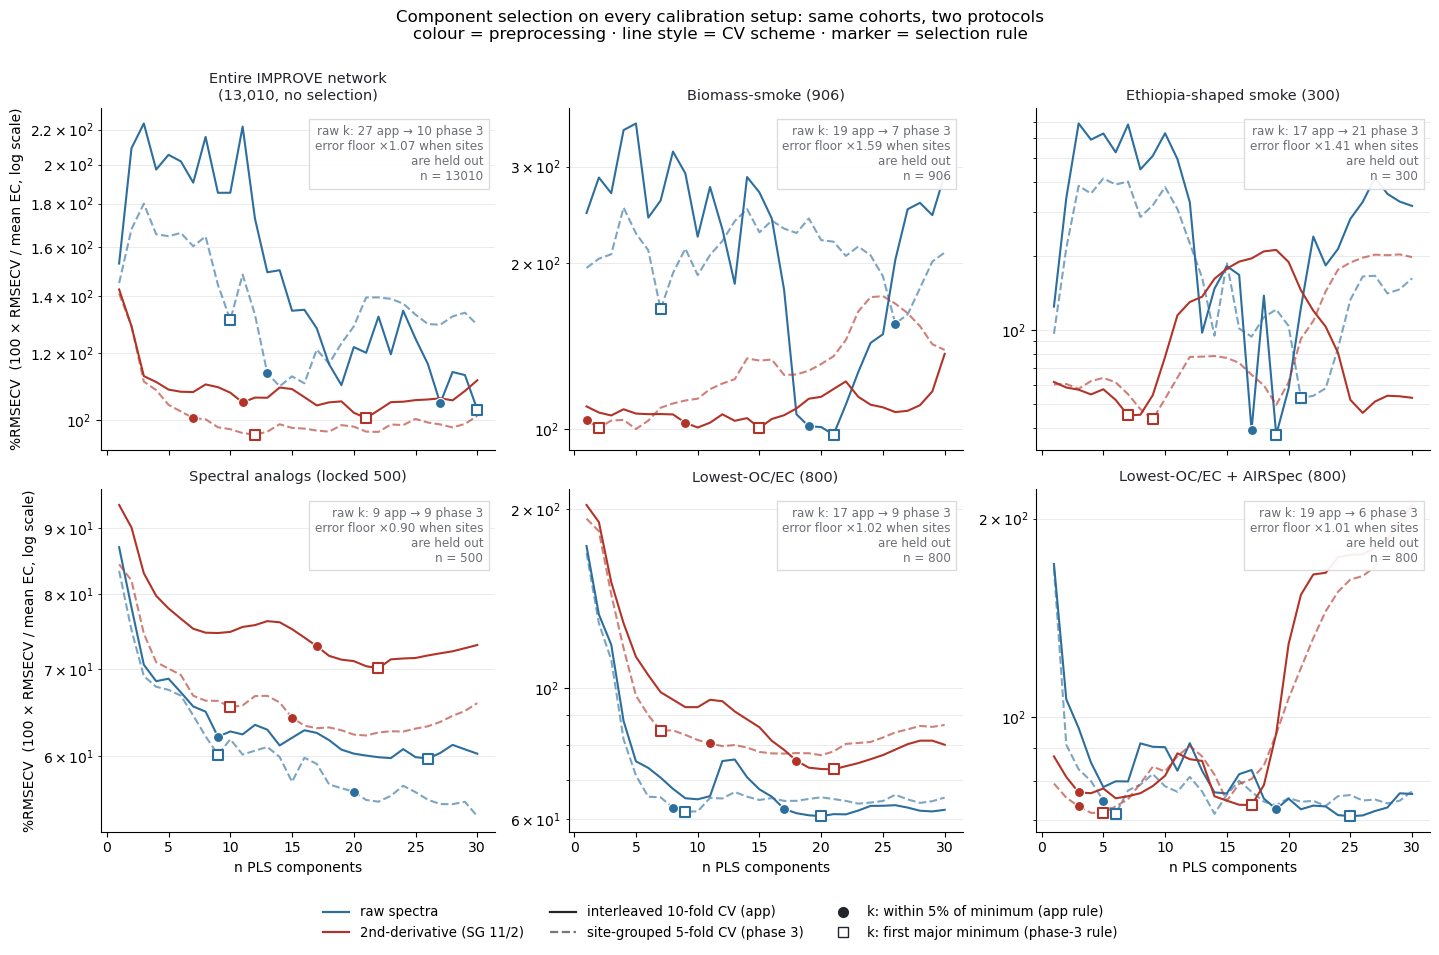

In [7]:
PANEL_ORDER = list(cohort_ids)
fig, axes = plt.subplots(2, 3, figsize=(14.5, 8.8), sharex=True)
for ax, name in zip(axes.flat, PANEL_ORDER):
    for preprocessing, colour in (('raw', RAW_COLOUR), ('2nd-derivative', D2_COLOUR)):
        for scheme, style in (('interleaved 10-fold', '-'), ('site-grouped 5-fold', '--')):
            curve = curves[(name, preprocessing, scheme)]
            ks = curve['n_components'].to_numpy()
            pct = curve['pct_rmsecv'].to_numpy()
            ax.plot(ks, pct, style, color=colour, lw=1.5,
                    alpha=1 if style == '-' else .62)
            k_app = select_within_tolerance(curve)
            k_p3, _ = select_first_major_minimum(curve.rename(columns={'rmsecv': 'rmse_mean'}))
            ax.scatter([k_app], [pct[list(ks).index(k_app)]], s=52, color=colour,
                       zorder=5, edgecolors='white', lw=.8)
            ax.scatter([k_p3], [pct[list(ks).index(k_p3)]], s=58, marker='s',
                       facecolors='white', edgecolors=colour, lw=1.5, zorder=6)
    interleaved = curves[(name, 'raw', 'interleaved 10-fold')]
    grouped = curves[(name, 'raw', 'site-grouped 5-fold')]
    ax.set_title(name, fontsize=10.5, color=INK)
    ratio = grouped['pct_rmsecv'].min() / interleaved['pct_rmsecv'].min()
    ax.text(.97, .95,
            f'raw k: {select_within_tolerance(interleaved)} app'
            f' → {select_first_major_minimum(grouped.rename(columns={"rmsecv": "rmse_mean"}))[0]}'
            f' phase 3\n'
            f'error floor ×{ratio:.2f} when sites\nare held out\nn = {len(cohort_ids[name])}',
            transform=ax.transAxes, va='top', ha='right', fontsize=8.6, color=MUTED,
            bbox=dict(facecolor='white', edgecolor='0.85', alpha=.92))
    # Log y: the raw interleaved curves spike to several hundred percent on the smoke
    # cohorts, which would flatten the floor region that the selection rules act on.
    ax.set_yscale('log')
    ax.grid(axis='y', color='0.92', lw=.7, which='both')
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
for ax in axes[1]:
    ax.set_xlabel('n PLS components')
for ax in axes[:, 0]:
    ax.set_ylabel('%RMSECV  (100 × RMSECV / mean EC, log scale)')
fig.legend(handles=[
    Line2D([], [], color=RAW_COLOUR, lw=1.6, label='raw spectra'),
    Line2D([], [], color=D2_COLOUR, lw=1.6, label='2nd-derivative (SG 11/2)'),
    Line2D([], [], color=INK, lw=1.6, ls='-', label='interleaved 10-fold CV (app)'),
    Line2D([], [], color=INK, lw=1.6, ls='--', alpha=.62, label='site-grouped 5-fold CV (phase 3)'),
    Line2D([], [], color=INK, marker='o', ls='', markersize=7, label='k: within 5% of minimum (app rule)'),
    Line2D([], [], color=INK, marker='s', ls='', markersize=7, markerfacecolor='white',
           label='k: first major minimum (phase-3 rule)'),
], loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(.5, -.07), fontsize=9.5)
fig.suptitle('Component selection on every calibration setup: same cohorts, two protocols\n'
             'colour = preprocessing · line style = CV scheme · marker = selection rule',
             y=1.0)
fig.tight_layout()
for target in (PLOT_DIR / 'component_selection_all_setups.png',
               DECK_DIR / 'component_selection_all_setups.png'):
    fig.savefig(target, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

### 6. The deck strip: k under each rule, per setup

The same four numbers per cohort as a ladder — how far apart the two protocols land.

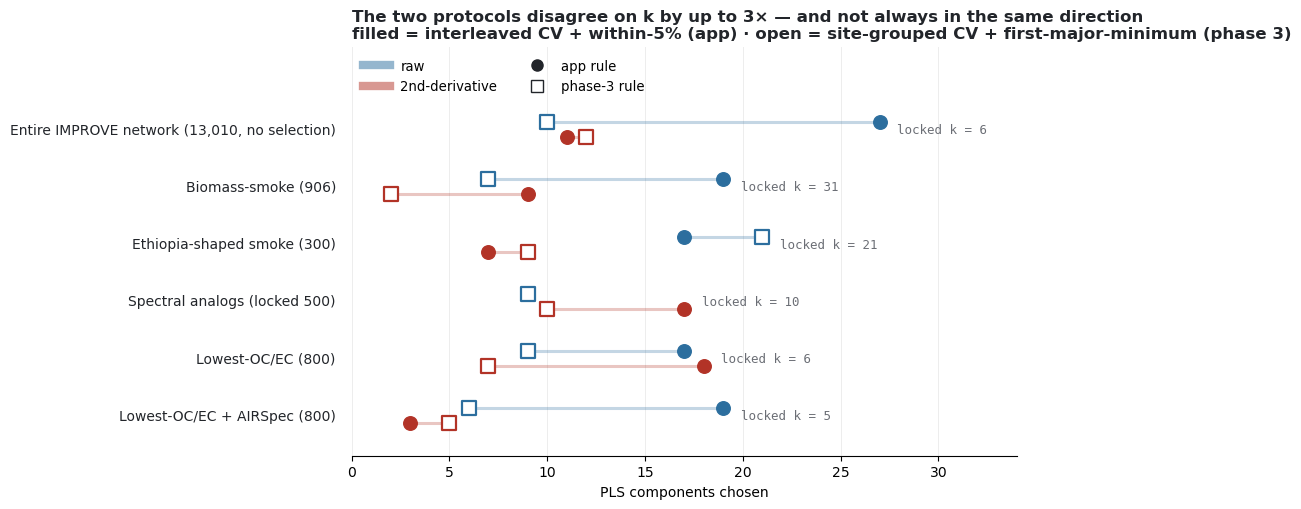

In [8]:
fig, ax = plt.subplots(figsize=(10.4, 5.2))
rows = PANEL_ORDER[::-1]
for yi, name in enumerate(rows):
    values = []
    for preprocessing, colour in (('raw', RAW_COLOUR), ('2nd-derivative', D2_COLOUR)):
        k_app = select_within_tolerance(curves[(name, preprocessing, 'interleaved 10-fold')])
        k_p3, _ = select_first_major_minimum(
            curves[(name, preprocessing, 'site-grouped 5-fold')]
            .rename(columns={'rmsecv': 'rmse_mean'}))
        offset = .13 if preprocessing == 'raw' else -.13
        ax.plot([k_p3, k_app], [yi + offset] * 2, color=colour, lw=2.2, alpha=.28, zorder=2)
        ax.scatter([k_app], [yi + offset], s=95, color=colour, zorder=3)
        ax.scatter([k_p3], [yi + offset], s=95, marker='s', facecolors='white',
                   edgecolors=colour, lw=1.6, zorder=3)
        values += [k_app, k_p3]
    ax.text(-.8, yi, name.replace('\n', ' '), ha='right', va='center', fontsize=10, color=INK)
    ax.text(max(values) + .9, yi, f'locked k = {int(LOCKED.set_index("cohort").loc[name.replace(chr(10), " "), "locked_k"])}',
            va='center', fontsize=9, color=MUTED, fontfamily='monospace')
ax.set_yticks([])
ax.set_ylim(-.7, len(rows) - .3 + .75)   # headroom so the legend clears the top row
ax.set_xlim(0, MAX_COMPONENTS + 4)
ax.set_xlabel('PLS components chosen')
ax.set_title('The two protocols disagree on k by up to 3× — and not always in the same '
             'direction\n'
             'filled = interleaved CV + within-5% (app) · open = site-grouped CV + '
             'first-major-minimum (phase 3)',
             fontsize=12, fontweight='bold', color=INK, loc='left')
ax.legend(handles=[
    Line2D([], [], color=RAW_COLOUR, lw=6, alpha=.5, label='raw'),
    Line2D([], [], color=D2_COLOUR, lw=6, alpha=.5, label='2nd-derivative'),
    Line2D([], [], color=INK, marker='o', ls='', markersize=8, label='app rule'),
    Line2D([], [], color=INK, marker='s', ls='', markersize=8, markerfacecolor='white',
           label='phase-3 rule'),
], loc='upper left', frameon=False, fontsize=9.5, ncol=2)
for spine in ('top', 'right', 'left'):
    ax.spines[spine].set_visible(False)
ax.grid(axis='x', color='0.93', lw=.7)
ax.set_axisbelow(True)
fig.tight_layout()
for target in (PLOT_DIR / 'k_by_rule_ladder.png', DECK_DIR / 'k_by_rule_ladder.png'):
    fig.savefig(target, dpi=190, bbox_inches='tight', facecolor='white')
plt.show()

## Takeaways

- **Report the CV scheme with every k.** The same cohort and the same spectra give k = 27
  or k = 10 depending only on whether folds respect site boundaries. Any comparison of
  component counts across the two projects is meaningless without it.
- **The leakage penalty is cohort-specific, and it indicts the smoke lineage specifically.**
  A ×1.59 (smoke-906) and ×1.41 (Ethiopia-shaped) inflation from interleaved folds, versus
  ×1.01–1.07 for the pool and the lowest-OC/EC cohorts, says the deployed family's apparent
  skill leans on having seen its own sites. This is an independent, protocol-level reason
  to distrust the smoke-906 calibration at Addis — a site it has never seen — alongside
  ftir_13's finding that it collapses on corrected spectra.
- **The lowest-OC/EC cohort is robust to this whole argument** (×1.02 raw, ×1.01 AIRSpec):
  its skill does not depend on the fold structure, which is what you want from a cohort
  meant to transfer to a new site.
- **Second-derivative preprocessing is not a free win.** It rescues the baseline-dominated
  cohorts and degrades the AIRSpec-corrected one — the two are alternative fixes for the
  same problem, so applying both is not additive. Weakley's argument for choosing k on
  2nd-derivative spectra applies to the raw-spectra calibrations, not to phase 3's.
- **What the site leakage actually buys is baseline structure.** On second-derivative
  spectra the optimism ratio collapses to **0.89–1.06 for every cohort** — including
  smoke-906, which falls from ×1.59 to ×1.00. Removing the smooth baseline removes the
  advantage of having seen a site before, so the thing an interleaved fold leaks is the
  site's characteristic background, not its chemistry. That is the same quantity ftir_19's
  AIRSpec explainer shows Addis carries in excess, and it closes the loop with ftir_13:
  raw-spectra models regress on site background, which is exactly what fails to transfer.
- **Caveats**: the matrix's "Deployed SPARTAN" row appears here as the **entire IMPROVE
  network** (13,010 filters, no selection) because that is what it is on the training
  side — the deployed model is a network calibration trained on IMPROVE, and the only
  SPARTAN spectra in this project are ETAD's, which are the evaluation set and never
  training data; the locked analog cohort is
  the top 500, not the matrix's superseded "400"; curves are computed on each *full*
  cohort while the locked k values were selected on training splits, so the two need not
  coincide exactly; and the first-major-minimum rule needs a per-fold standard error, which
  a pooled interleaved RMSECV curve does not have — on those curves it degenerates to the
  global minimum, which is why each rule is paired with its own scheme in the figures.